In [21]:
# libraries that are needed
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [22]:
df = pd.read_csv("water_potability.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [23]:
#to check basic info for missing values
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [24]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [25]:
#used mean imputation for null values(safe and standard for numeric data)
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
#check again for null values
df_imputed.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [26]:
#seprating feature and the target varibales
X = df_imputed.drop("Potability", axis=1)
y = df_imputed["Potability"]

In [27]:
#data spliitng for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
#feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
#importing SVM and evlaute libraries
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, cross_val_score

#Visulizations libraries
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
# Hyperparameter Tuning (GridSearchCV)
# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

In [31]:
# Create base SVM model
svm = SVC()

In [32]:
# Grid search to find best parameters
grid_search = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


In [33]:
# Train models
grid_search.fit(X_train_scaled, y_train)
print("\nBest Parameters Found:")
print(grid_search.best_params_)


Best Parameters Found:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [34]:
# Train final model
best_svm = grid_search.best_estimator_
print("\nTraining final SVM model...")
best_svm.fit(X_train_scaled, y_train)


Training final SVM model...


,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [35]:
# cross validation
cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=5) 
print("\nCross Validation Scores:", cv_scores) 
print("Average CV Score:", np.mean(cv_scores))


Cross Validation Scores: [0.67175573 0.67748092 0.6889313  0.70038168 0.67175573]
Average CV Score: 0.6820610687022901


In [36]:
# Make predication
y_pred = best_svm.predict(X_test_scaled)

In [ ]:
# Accuracy 
accuracy = accuracy_score(y_test, y_pred) 
print("\nModel Accuracy:", accuracy) 

# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred) 
print("\nConfusion Matrix:") 
print(cm)

# Classification Report 
print("\nClassification Report:") 
print(classification_report(y_test, y_pred))

# weighted
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nAdditional Metrics (Weighted):")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Model Accuracy: 0.6692073170731707

Confusion Matrix:
[[370  30]
 [187  69]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      0.93      0.77       400
         1.0       0.70      0.27      0.39       256

    accuracy                           0.67       656
   macro avg       0.68      0.60      0.58       656
weighted avg       0.68      0.67      0.62       656



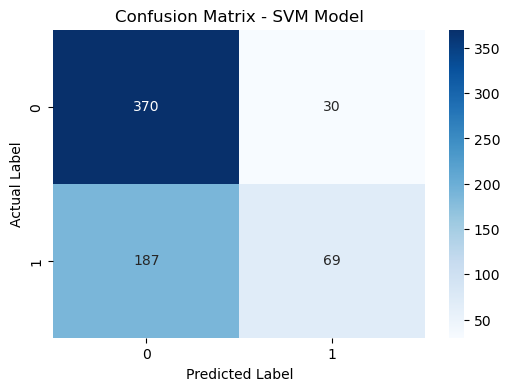

In [ ]:
# confusion metrix visulizations
plt.figure(figsize=(6,4)) 
sns.heatmap( cm, annot=True, fmt='d', cmap='Blues' ) 
plt.title("Confusion Matrix - SVM Model") 
plt.xlabel("Predicted Label") 
plt.ylabel("Actual Label") 
plt.show()

In [ ]:
# ROC Curve Visualization

from sklearn.metrics import roc_curve, auc

# Get decision scores (not probabilities)
y_scores = best_svm.decision_function(X_test_scaled)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # random guess line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM Model")

plt.legend()
plt.grid()

plt.show()

In [ ]:
# Manual Prediction (For manual checking of a sample)

input_data = pd.DataFrame([{
    "ph": 7.5,
    "Hardness": 180,
    "Solids": 20000,
    "Chloramines": 7.0,
    "Sulfate": 330,
    "Conductivity": 400,
    "Organic_carbon": 14,
    "Trihalomethanes": 65,
    "Turbidity": 4.0
}])

# Apply scaling
input_scaled = scaler.transform(input_data)

# Predict
prediction = best_svm.predict(input_scaled)

# Output result
if prediction[0] == 1:
    print("\n Water is SAFE to drink")
else:
    print("\n Water is NOT safe to drink")